<a href="https://colab.research.google.com/github/AlinaKruzhkova/University/blob/main/neural_networks/%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [1]:
!pip install tensorflow scikit-learn gradio matplotlib

In [14]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
data = raw_df.values[1::2, 2]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1764/3900670415.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [15]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Загрузка Boston Housing через scikit-learn
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = boston.data.values
y = boston.target.values

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация (критично для ИНС)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (404, 13), Test: (102, 13)


#### 1.2. Проектируем архитектуру для этой задачи

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [17]:
model.compile(
    optimizer='adam',
    loss='mse', #
    metrics=['mae'] #
)

#### 1.4. Обучаем модель ИНС

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - loss: 579.8647 - mae: 22.1979 - val_loss: 486.9977 - val_mae: 20.2822
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 530.1437 - mae: 20.9781 - val_loss: 430.9100 - val_mae: 18.8097
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 454.7606 - mae: 19.0619 - val_loss: 340.5104 - val_mae: 16.3737
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 336.5146 - mae: 15.9912 - val_loss: 214.5786 - val_mae: 12.6776
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 189.9015 - mae: 11.5372 - val_loss: 92.7011 - val_mae: 7.9889
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 87.5639 - mae: 7.4210 - val_loss: 51.3691 - val_mae: 5.2734
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 54.0852 - mae: 5.7124 - val_loss: 38.4729 - val_mae: 4.3191
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36.6324 - mae: 4.5201 - val_loss: 32.2719 - val_mae: 3.7989
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━

#### 1.6. Делаем предсказания на тестовых данных

In [11]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [19]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_pred, y_test)

2.113800810832603

#### 1.8. Строим график обучения

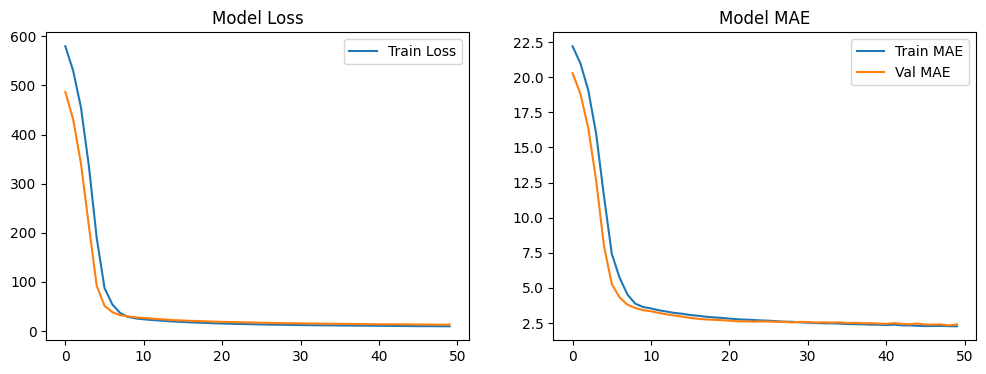

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.legend()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

#### 2. Проверка обученной модели пользовательскими данными

## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [21]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense, Conv2D

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 3. Указываем путь к набору данных:

In [22]:
DATASET_PATH = "/content/drive/MyDrive/NN"
IMAGE_SIZE = (128, 128)

### 4. Загружаем набор данных и формируем общую выборку:

In [23]:
# Инициализация данных
data = []
labels = []

# Перебор классов
class_names = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {class_names}")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_paths = list(paths.list_images(class_path))

    # Берем первые 1000 изображений каждого класса
    image_paths = image_paths[:1010]

    for img_path in image_paths:
        # Загрузка и предобработка
        image = cv2.imread(img_path)
        image = cv2.resize(image, IMAGE_SIZE)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        data.append(image)
        labels.append(class_name)

print(f"Загружено {len(data)} изображений")

Классы: ['cat', 'rabbit', 'snake']
Загружено 3030 изображений


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [24]:
# Нормализация в [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
print(f"Форма данных: {data.shape}, метки: {labels.shape}")

Форма данных: (3030, 128, 128, 3), метки: (3030,)


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [25]:
(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.25,
                                                  stratify=labels,
                                                  random_state=42)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка: {testX.shape}")

Обучающая выборка: (2272, 128, 128, 3)
Тестовая выборка: (758, 128, 128, 3)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout

model = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(256, activation='relu'),
   # Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,595,843 (193.01 MB)

 Trainable params: 50,595,843 (193.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [27]:
INIT_LR = 0.0000001
EPOCHS = 80
BS = 128

#### 5.3. Компилируем модель:

In [28]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
callbacks = [
    ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#### 6.2. Запустим процесс обучения модели:

In [30]:
history = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=BS,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3238 - loss: 1.2563
Epoch 1: val_accuracy improved from None to 0.29288, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 695ms/step - accuracy: 0.3195 - loss: 1.2279 - val_accuracy: 0.2929 - val_loss: 1.1774
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3119 - loss: 1.1587
Epoch 2: val_accuracy did not improve from 0.29288
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3116 - loss: 1.1522 - val_accuracy: 0.2836 - val_loss: 1.1463
Epoch 3/80
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3113 - loss: 1.1320
Epoch 3: val_accuracy improved from 0.29288 to 0.29947, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - accuracy: 0.3244 - loss: 1.1298 - val_accuracy: 0.2995 - val_loss: 1.1325
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 

#### 6.3. Загружаем лучшую модель:

In [31]:
model.save('/content/drive/MyDrive/NN/best_model_img.keras')

In [32]:
model.load_weights("best_model.keras")

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [33]:
predictions = model.predict(testX)
print(classification_report(testY.argmax(axis=1),
                          predictions.argmax(axis=1),
                          target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

         cat       0.67      0.62      0.64       252
      rabbit       0.60      0.73      0.66       253
       snake       0.73      0.62      0.67       253

    accuracy                           0.66       758
   macro avg       0.66      0.66      0.66       758
weighted avg       0.66      0.66      0.66       758



#### 7.2. Выведем матрицу ошибок

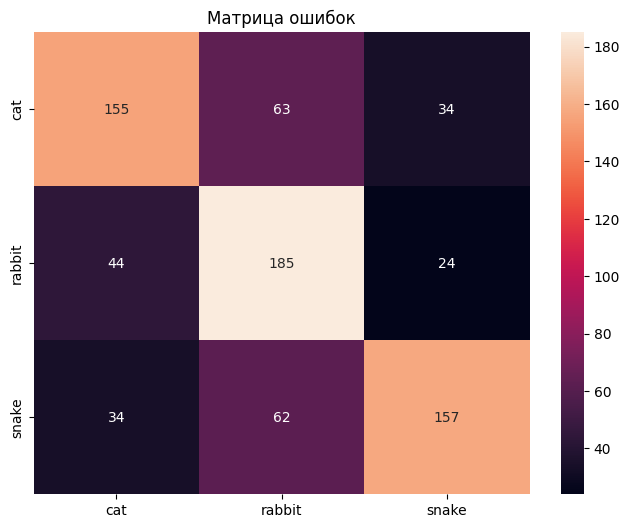

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.show()

#### 7.3. Отобразим график обучения

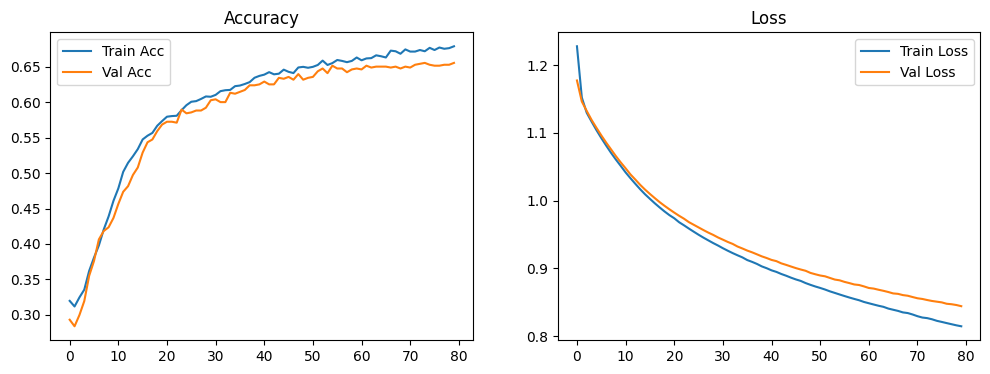

In [35]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

### 8. Сохранение модели и меток классов:

In [36]:
model.save('/content/drive/MyDrive/NN/final_image_classifier.keras')
# Сохранение меток классов
with open('/content/drive/MyDrive/NN/lb.pickle', 'wb') as f:
    pickle.dump(lb, f)
with open('/content/drive/MyDrive/NN/class_names.txt', 'w') as f:
    f.write('\n'.join(class_names))
print(" Модель сохранена!")

 Модель сохранена!


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
import gradio as gr

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [37]:
def preprocess_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.resize(image, IMAGE_SIZE)
    image = image.astype("float") / 255.0
    image = np.expand_dims(image, axis=0)
    return image

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [38]:
def predict_image(image):
    processed = preprocess_image(image)
    predictions = model.predict(processed)[0]
    class_idx = np.argmax(predictions)
    confidence = predictions[class_idx] * 100

    return {
        class_names[class_idx]: f"{confidence:.1f}%",
        'all': dict(zip(class_names, [f"{p*100:.1f}%" for p in predictions]))
    }

In [49]:
test_images = [
    "/content/drive/MyDrive/NN/snake/6.jpg",
    "/content/drive/MyDrive/NN/rabbit/_rabbit..205 (104).jpg",
    "/content/drive/MyDrive/NN/cat/173.jpg"
]

for img_path in test_images:
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print(f"\n  {os.path.basename(img_path)}")
    result = predict_image(image)
    print(result)



  6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
{'snake': '48.8%', 'all': {'cat': '40.9%', 'rabbit': '10.3%', 'snake': '48.8%'}}

  _rabbit..205 (104).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
{'rabbit': '49.1%', 'all': {'cat': '31.7%', 'rabbit': '49.1%', 'snake': '19.3%'}}

  173.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
{'cat': '44.9%', 'all': {'cat': '44.9%', 'rabbit': '25.6%', 'snake': '29.6%'}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


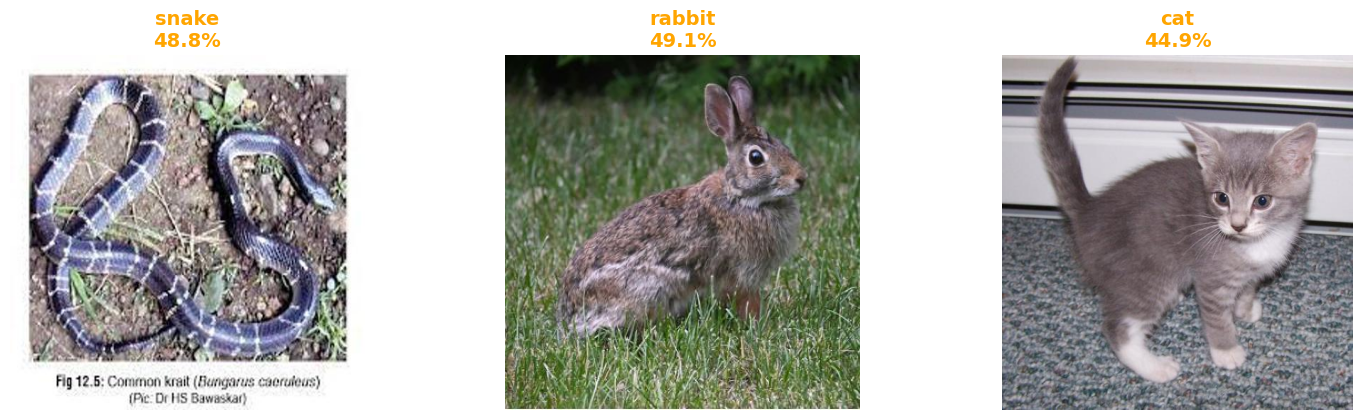

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

test_images = [
    "/content/drive/MyDrive/NN/snake/6.jpg",
    "/content/drive/MyDrive/NN/rabbit/_rabbit..205 (104).jpg",
    "/content/drive/MyDrive/NN/cat/173.jpg"
]

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

for i, img_path in enumerate(test_images[:6]):
    try:
        # Загружаем изображение
        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Предсказание
        result = predict_image(image_rgb)
        predicted_class = list(result.keys())[0]
        confidence = result[predicted_class].replace('%', '')

        ax = fig.add_subplot(gs[i//3, i%3])
        ax.imshow(image_rgb)
        ax.axis('off')

        title = f"{predicted_class}\n{confidence}%"
        ax.set_title(title, fontsize=14, fontweight='bold',
                    color='green' if confidence[:-1] > '80' else 'orange')

    except Exception as e:
        print(f"Ошибка загрузки {img_path}: {e}")

plt.tight_layout()
plt.show()


### 10. Визуализируем интерфейс и произведем классификацию: